In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, RocCurveDisplay


In [12]:
# load data set 
train = pd.read_csv('./train.csv')
train.drop(columns=["Loan_ID"], inplace=True)


In [13]:
# gettinginfo for data for preprocessing 
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Gender             601 non-null    str    
 1   Married            611 non-null    str    
 2   Dependents         599 non-null    str    
 3   Education          614 non-null    str    
 4   Self_Employed      582 non-null    str    
 5   ApplicantIncome    614 non-null    int64  
 6   CoapplicantIncome  614 non-null    float64
 7   LoanAmount         592 non-null    float64
 8   Loan_Amount_Term   600 non-null    float64
 9   Credit_History     564 non-null    float64
 10  Property_Area      614 non-null    str    
 11  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(7)
memory usage: 57.7 KB


In [14]:
mode_cols = ["Gender", "Married", "Dependents", "Education", "Self_Employed"]
for col in mode_cols:
    train[col] = train[col].fillna(train[col].mode()[0])

train["LoanAmount"]       = train["LoanAmount"].fillna(train["LoanAmount"].median())
train["Loan_Amount_Term"] = train["Loan_Amount_Term"].fillna(train["Loan_Amount_Term"].median())
train["Credit_History"]   = train["Credit_History"].fillna(train["Credit_History"].median())


In [15]:
train["Total_Income"]      = train["ApplicantIncome"] + train["CoapplicantIncome"]
train["Income_Loan_Ratio"] = train["Total_Income"] / (train["LoanAmount"] + 1)
train["EMI"]               = train["LoanAmount"] / (train["Loan_Amount_Term"] + 1)


In [16]:
le = LabelEncoder()
binary_cols = ["Gender", "Married", "Education", "Self_Employed", "Loan_Status"]
for col in binary_cols:
    train[col] = le.fit_transform(train[col])

# Dependents: 0,1,2,3+ → ordinal makes more sense
train["Dependents"] = train["Dependents"].replace("3+", "3").astype(int)

oe = OrdinalEncoder(categories=[["Rural", "Semiurban", "Urban"]])
train["Property_Area"] = oe.fit_transform(train[["Property_Area"]])


In [17]:
X = train.drop(columns=["Loan_Status"])
y = train["Loan_Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [18]:
scaler = StandardScaler()
scale_cols = ["ApplicantIncome", "CoapplicantIncome", "LoanAmount",
              "Loan_Amount_Term", "Total_Income", "Income_Loan_Ratio", "EMI"]
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])   # ← transform only!


In [19]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"  ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}")
    print(classification_report(y_test, y_pred, target_names=["Rejected", "Approved"]))



  Logistic Regression
  Accuracy : 0.8618
  ROC-AUC  : 0.8006
              precision    recall  f1-score   support

    Rejected       0.96      0.58      0.72        38
    Approved       0.84      0.99      0.91        85

    accuracy                           0.86       123
   macro avg       0.90      0.78      0.81       123
weighted avg       0.88      0.86      0.85       123


  Random Forest
  Accuracy : 0.8537
  ROC-AUC  : 0.8472
              precision    recall  f1-score   support

    Rejected       0.79      0.71      0.75        38
    Approved       0.88      0.92      0.90        85

    accuracy                           0.85       123
   macro avg       0.84      0.81      0.82       123
weighted avg       0.85      0.85      0.85       123


  Gradient Boosting
  Accuracy : 0.7967
  ROC-AUC  : 0.7635
              precision    recall  f1-score   support

    Rejected       0.72      0.55      0.63        38
    Approved       0.82      0.91      0.86        85

 

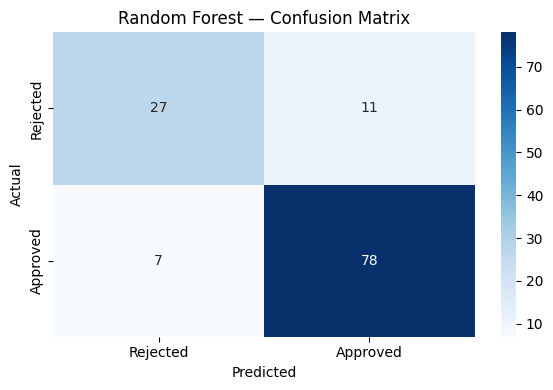

In [20]:
best_model = models["Random Forest"]
y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best),
            annot=True, fmt='d', cmap='Blues',
            xticklabels=["Rejected", "Approved"],
            yticklabels=["Rejected", "Approved"])
plt.title("Random Forest — Confusion Matrix")
plt.ylabel("Actual"); plt.xlabel("Predicted")
plt.tight_layout(); plt.show()

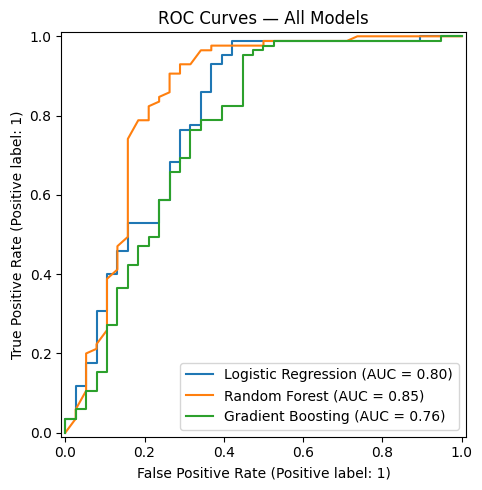

In [21]:
fig, ax = plt.subplots(figsize=(6, 5))
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=name)
ax.set_title("ROC Curves — All Models")
plt.tight_layout(); plt.show()


C:\Users\USER\AppData\Local\Temp\ipykernel_12332\2748156702.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")


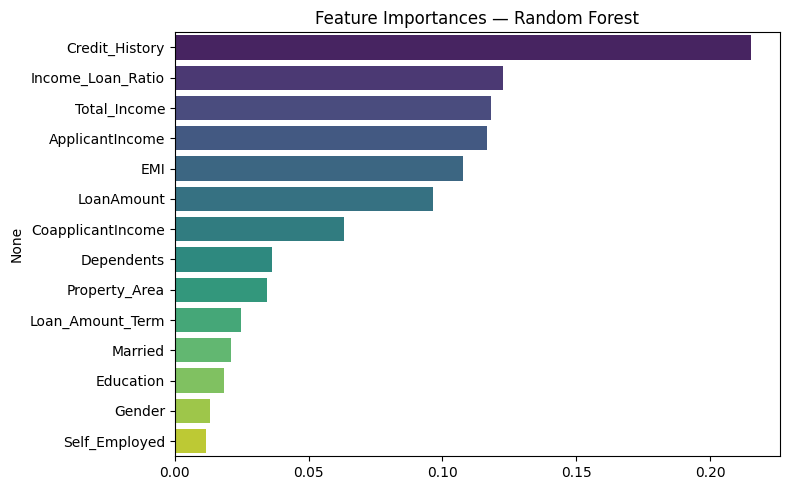

In [22]:
feat_imp = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette="viridis")
plt.title("Feature Importances — Random Forest")
plt.tight_layout(); plt.show()